In [226]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_tenure_sorting import ModelClass
# from Old_models.main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

from graphs import *

import copy


# params_to_latex(par)

# np.set_printoptions(threshold=np.inf)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Increase chance of being reassigned

In [227]:
# Baseline
model = ModelClass()
model.solve(do_print=False)


In [228]:
first_period = 10
second_period = 20

rho_baseline = model.par.rho.copy()

# Periods 0–9: baseline
model.par.rho = rho_baseline.copy()
model.par.T_max = first_period
model.generate_transition(t_end=first_period - 1, do_print=False)
sol1 = copy.deepcopy(model.sol)

# Initial steady-state period plus 20 shocked periods
rho_shock = rho_baseline.copy()
rho_shock[20:-1] = rho_baseline[20:-1] ** 0.25
model.par.rho = rho_shock
model.par.T_max = second_period + 1
model.generate_transition(t_end=second_period, do_print=False)
sol2 = copy.deepcopy(model.sol)

# Drop sol2 period 0 because it duplicates the pre-shock steady state
for name, x1 in vars(sol1).items():
    x2 = getattr(sol2, name)

    if (
        isinstance(x1, np.ndarray)
        and isinstance(x2, np.ndarray)
        and x1.ndim >= 1
        and x2.ndim == x1.ndim
        and x1.shape[0] == first_period
        and x2.shape[0] == second_period + 1
        and x1.shape[1:] == x2.shape[1:]
    ):
        setattr(
            model.sol,
            name,
            np.concatenate((x1, x2[1:]), axis=0),
        )

model.par.T_max = first_period + second_period

In [229]:

np.mean(model.sol.l_h[0, :, :], axis = 1)

array([0.37708313, 0.37948641, 0.37971207, 0.37979694, 0.37984141,
       0.37986875, 0.37988724, 0.37990056, 0.37991061, 0.37991845,
       0.37992473, 0.37992987, 0.37993414, 0.37993775, 0.37994084,
       0.3799435 , 0.37994582, 0.37994786, 0.37994966, 0.37995126,
       0.37995269, 0.37995397, 0.37995513, 0.37995618, 0.37995714,
       0.37995801, 0.3799588 , 0.37995953, 0.3799602 , 0.37996082,
       0.        ])

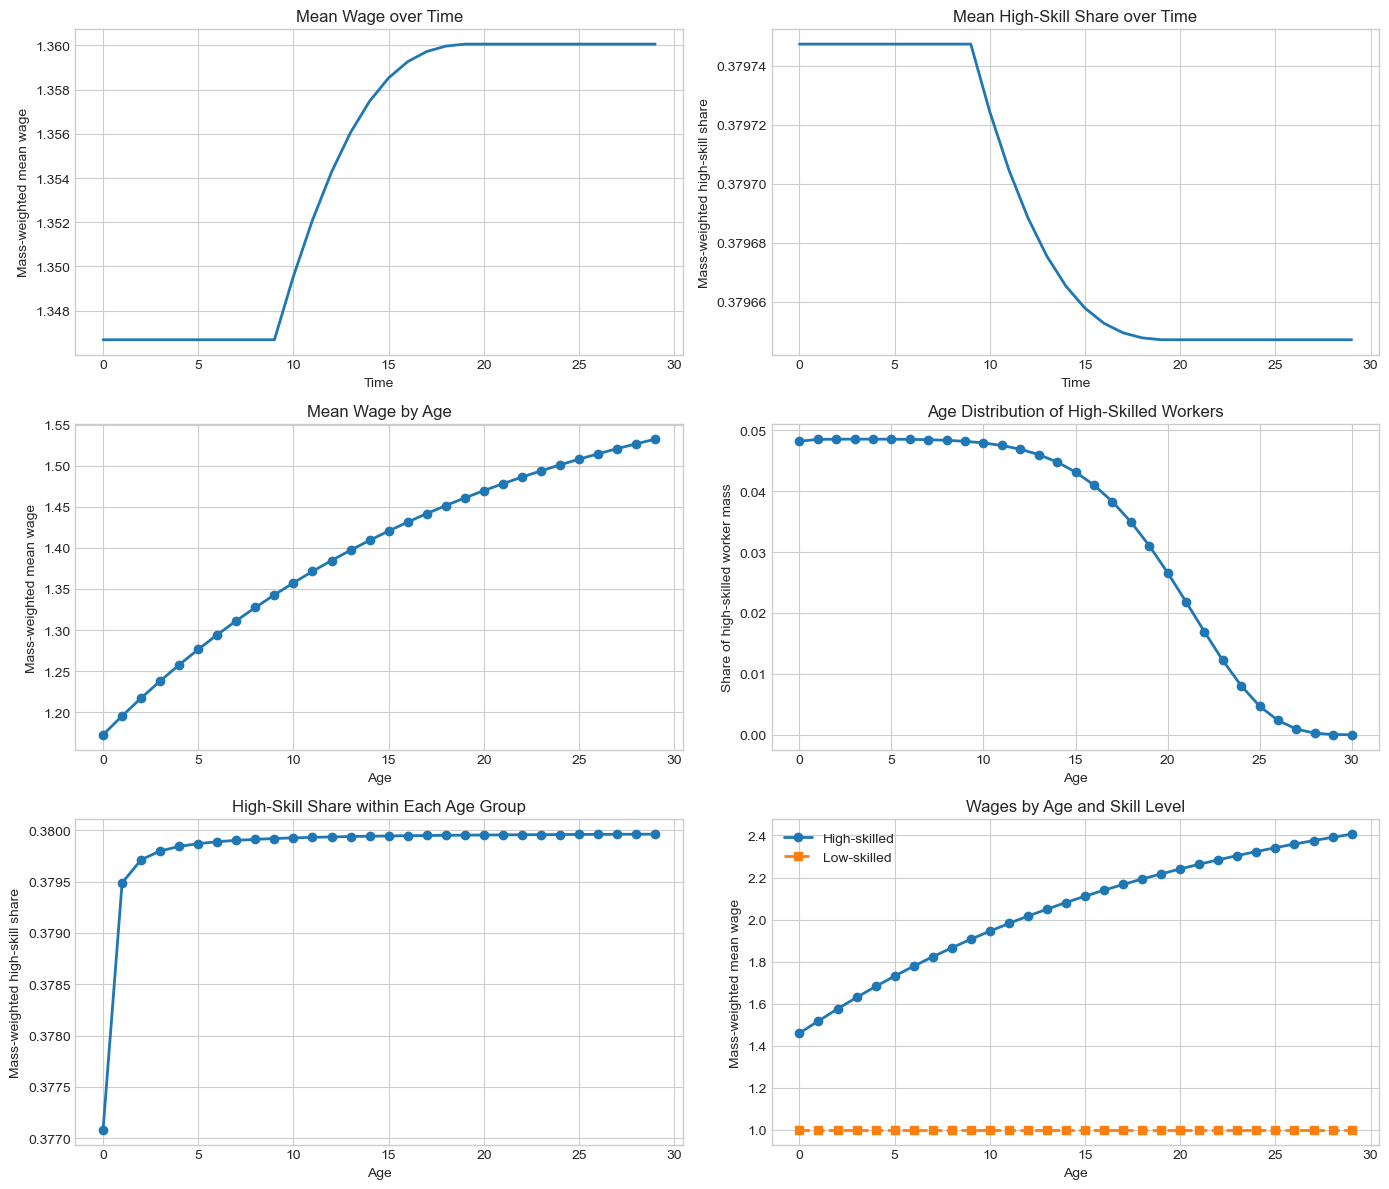

In [230]:
plot_model(model, time = first_period)

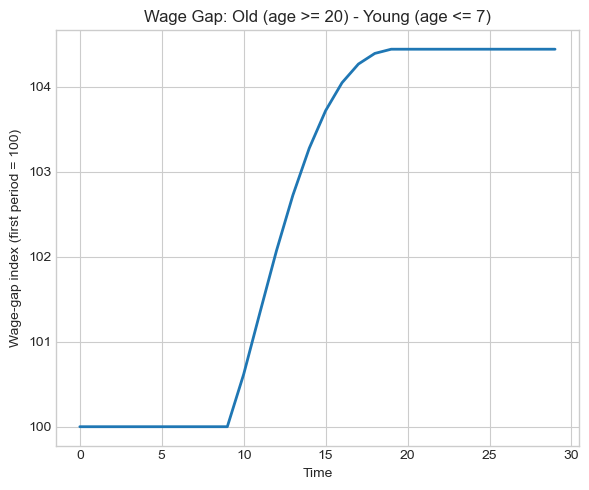

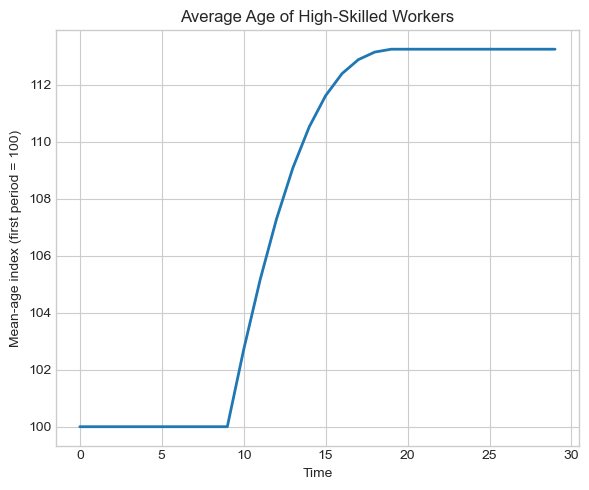

In [231]:
plot_wage_gap(model, young_max=7, old_min=20, x_size=6, y_size=5)
plot_mean_age_high_skill(model, x_size=6, y_size=5)

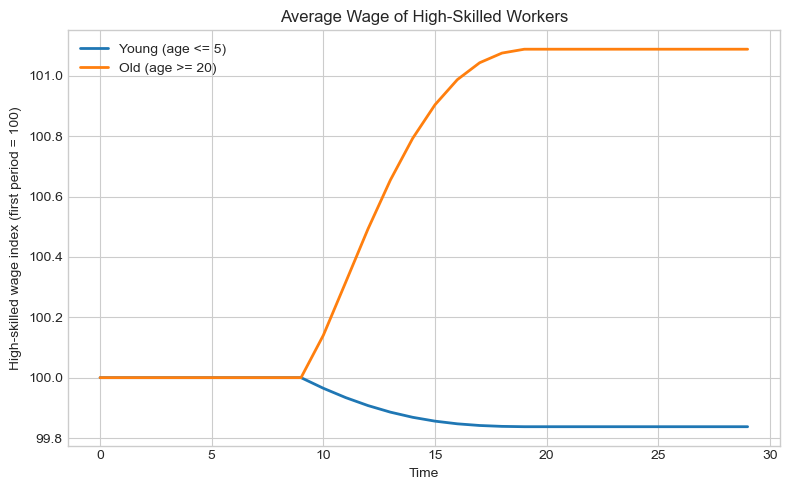

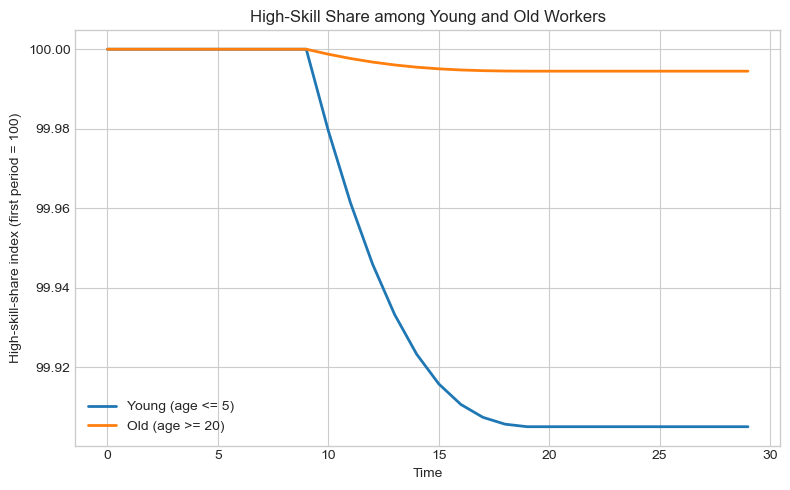

In [232]:
plot_high_skill_wages_young_old(model, young_max=5, old_min=20)
plot_high_skill_shares_young_old(model, young_max=5, old_min=20)

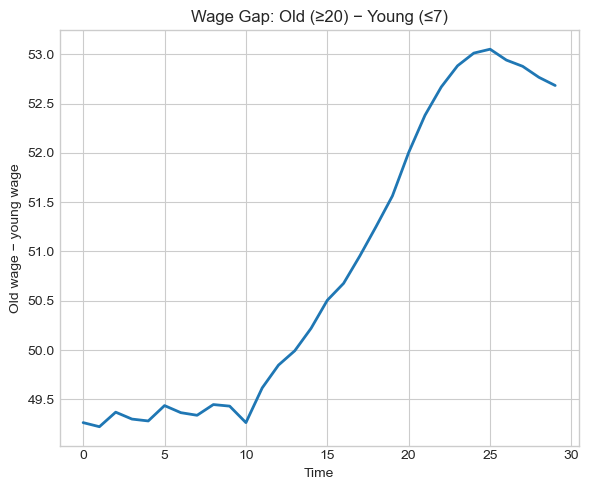

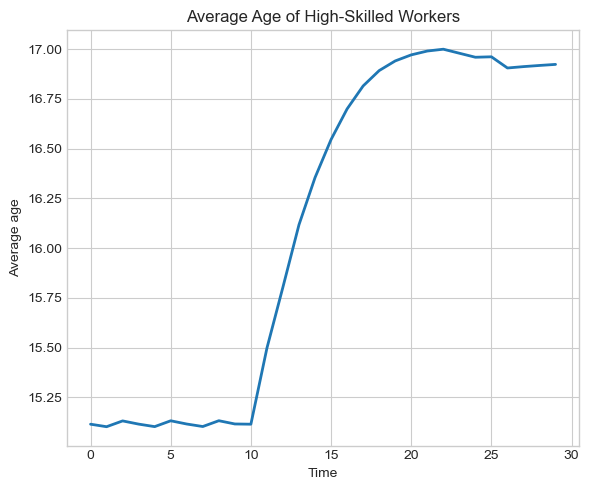